In [1]:
import sys
!{sys.executable} -m pip install scikit-learn xgboost joblib plotly --quiet

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import plotly.express as px
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/processed/matches_clean.csv')
team_summary = pd.read_csv('../data/processed/team_summary.csv')

print("✅ Loaded!")
print("Matches:", df.shape)
print("Teams:", team_summary.shape)
team_summary.head()

'G:\Claude' is not recognized as an internal or external command,
operable program or batch file.


✅ Loaded!
Matches: (964, 15)
Teams: (81, 5)


,Team,Games,Win_Rate,Avg_Goals,Recent_Form
0,Algeria,6,0.272727,1.000000,0.2
1,Angola,1,0.000000,0.000000,0.5
2,Argentina,63,0.597701,1.712644,1.0
3,Australia,8,0.166667,0.833333,0.2
4,Austria,14,0.440000,1.520000,0.0


In [2]:
# Build rich stats per team
teams = df['Home Team Name'].unique()
team_profiles = []

for team in teams:
    home = df[df['Home Team Name'] == team]
    away = df[df['Away Team Name'] == team]
    
    total_games = len(home) + len(away)
    if total_games < 3:
        continue
    
    goals_scored = home['Home Team Score'].sum() + away['Away Team Score'].sum()
    goals_conceded = home['Away Team Score'].sum() + away['Home Team Score'].sum()
    wins = home['Home Team Win'].sum() + away['Away Team Win'].sum()
    draws = home['Draw'].sum() + away['Draw'].sum()
    
    team_profiles.append({
        'Team': team,
        'Games': total_games,
        'Win Rate': round(wins / total_games, 3),
        'Draw Rate': round(draws / total_games, 3),
        'Goals Per Game': round(goals_scored / total_games, 3),
        'Conceded Per Game': round(goals_conceded / total_games, 3),
        'Goal Difference': round((goals_scored - goals_conceded) / total_games, 3),
        'Attack Score': round(goals_scored / total_games, 3),
        'Defense Score': round(1 - (goals_conceded / total_games / 3), 3),
    })

profiles_df = pd.DataFrame(team_profiles)
print("✅ Team profiles built for", len(profiles_df), "teams")
profiles_df.head(10)

✅ Team profiles built for 81 teams


,Team,Games,Win Rate,Draw Rate,Goals Per Game,Conceded Per Game,Goal Difference,Attack Score,Defense Score
0,France,73,0.562,0.123,1.863,1.164,0.699,1.863,0.612
1,United States,37,0.243,0.216,1.081,1.784,-0.703,1.081,0.405
2,Yugoslavia,37,0.432,0.189,1.622,1.243,0.378,1.622,0.586
3,Romania,21,0.381,0.143,1.429,1.524,-0.095,1.429,0.492
4,Argentina,88,0.602,0.114,1.727,1.148,0.580,1.727,0.617
5,Chile,33,0.333,0.182,1.212,1.485,-0.273,1.212,0.505
6,Uruguay,59,0.441,0.203,1.508,1.288,0.220,1.508,0.571
7,Brazil,114,0.693,0.123,2.079,0.947,1.132,2.079,0.684
8,Paraguay,27,0.296,0.333,1.111,1.407,-0.296,1.111,0.531
9,Austria,29,0.414,0.138,1.483,1.621,-0.138,1.483,0.460


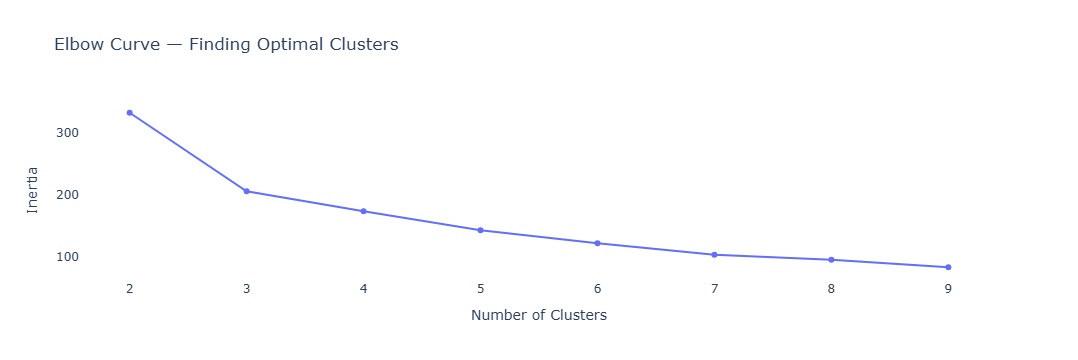

✅ Best number of clusters: 2
   Silhouette scores: [0.388, 0.381, 0.312, 0.303, 0.298, 0.311, 0.305, 0.324]


In [3]:
# Scale features for clustering
features_for_clustering = ['Win Rate', 'Draw Rate', 'Goals Per Game', 
                            'Conceded Per Game', 'Goal Difference',
                            'Attack Score', 'Defense Score']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(profiles_df[features_for_clustering])

# Try different numbers of clusters and find the best
inertias = []
silhouettes = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig = px.line(x=list(K), y=inertias,
              title='Elbow Curve — Finding Optimal Clusters',
              labels={'x': 'Number of Clusters', 'y': 'Inertia'},
              markers=True)
fig.update_layout(plot_bgcolor='white')
fig.show()

best_k = K[np.argmax(silhouettes)]
print(f"✅ Best number of clusters: {best_k}")
print(f"   Silhouette scores: {[round(s,3) for s in silhouettes]}")

In [4]:
# Use 4 clusters
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
profiles_df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_stats = profiles_df.groupby('Cluster')[features_for_clustering].mean()
print("Cluster averages:")
print(cluster_stats.round(3))

# Rank clusters and assign unique names
ranked = cluster_stats.copy()
remaining = list(range(k))

# Elite = highest win rate
elite = ranked.loc[remaining, 'Win Rate'].idxmax()
remaining.remove(elite)

# Attacking = highest goals per game from remaining
attack = ranked.loc[remaining, 'Goals Per Game'].idxmax()
remaining.remove(attack)

# Defensive = lowest conceded per game from remaining
defense = ranked.loc[remaining, 'Conceded Per Game'].idxmin()
remaining.remove(defense)

# Last one is developing
developing = remaining[0]

cluster_names = {
    elite: '🏆 Elite',
    attack: '⚔️ Attacking',
    defense: '🛡️ Defensive',
    developing: '📈 Developing'
}

print("\nCluster assignments:", cluster_names)

profiles_df['Play Style'] = profiles_df['Cluster'].map(cluster_names)

print("\n✅ Cluster labels assigned!")
print(profiles_df['Play Style'].value_counts())
print("\nSample teams per cluster:")
for style in ['🏆 Elite', '⚔️ Attacking', '🛡️ Defensive', '📈 Developing']:
    teams = profiles_df[profiles_df['Play Style'] == style]['Team'].head(4).tolist()
    print(f"  {style}: {', '.join(teams)}")

Cluster averages:
         Win Rate  Draw Rate  Goals Per Game  Conceded Per Game  \
Cluster                                                           
0           0.136      0.391           0.718              1.422   
1           0.074      0.058           0.608              3.515   
2           0.478      0.150           1.623              1.292   
3           0.226      0.159           0.922              1.690   

         Goal Difference  Attack Score  Defense Score  
Cluster                                                
0                 -0.704         0.718          0.526  
1                 -2.907         0.608         -0.172  
2                  0.331         1.623          0.569  
3                 -0.767         0.922          0.437  

Cluster assignments: {np.int32(2): '🏆 Elite', np.int32(3): '⚔️ Attacking', np.int32(0): '🛡️ Defensive', 1: '📈 Developing'}

✅ Cluster labels assigned!
Play Style
🏆 Elite         29
⚔️ Attacking    26
🛡️ Defensive    15
📈 Developing    11
Name

In [5]:
import plotly.io as pio
pio.renderers.default = "browser"

fig = px.scatter(profiles_df, 
                 x='Goals Per Game', 
                 y='Win Rate',
                 color='Play Style',
                 size='Games',
                 hover_name='Team',
                 title='World Cup Teams — Play Style Clusters',
                 color_discrete_map={
                     '🏆 Elite': '#1D9E75',
                     '⚔️ Attacking': '#378ADD', 
                     '🛡️ Defensive': '#BA7517',
                     '📈 Developing': '#D85A30'
                 },
                 size_max=40)

fig.update_layout(plot_bgcolor='white')
fig.show()

# Radar chart
categories = ['Win Rate', 'Goals Per Game', 'Defense Score', 
              'Attack Score', 'Draw Rate']

fig2 = go.Figure()
colors = ['#1D9E75', '#378ADD', '#BA7517', '#D85A30']
styles = ['🏆 Elite', '⚔️ Attacking', '🛡️ Defensive', '📈 Developing']

for style, color in zip(styles, colors):
    subset = profiles_df[profiles_df['Play Style'] == style]
    values = [subset[c].mean() for c in categories]
    values += values[:1]
    
    fig2.add_trace(go.Scatterpolar(
        r=values,
        theta=categories + [categories[0]],
        fill='toself',
        name=style,
        line_color=color
    ))

fig2.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title='Play Style Radar Chart by Cluster',
    showlegend=True
)
fig2.show()

In [6]:
import joblib
import random

# Load trained model
model = joblib.load('../backend/models/match_predictor.joblib')
le = joblib.load('../backend/models/label_encoder.joblib')
features_v2 = joblib.load('../backend/models/feature_names.joblib')

# 2026 World Cup teams (48 teams)
world_cup_2026_teams = [
    'Mexico', 'South Africa', 'Morocco', 'Haiti',
    'Canada', 'Bosnia and Herzegovina', 'Venezuela', 'Egypt',
    'Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay',
    'United States', 'Paraguay', 'Australia', 'Turkey',
    'Germany', 'Ivory Coast', 'Ecuador', 'Curacao',
    'Portugal', 'Nigeria', 'Colombia', 'New Zealand',
    'France', 'Belgium', 'Peru', 'South Korea',
    'England', 'Senegal', 'Netherlands', 'Panama',
    'Brazil', 'Japan', 'Croatia', 'Chile',
    'Argentina', 'Algeria', 'Austria', 'Jordan',
    'Serbia', 'Iran', 'Ghana', 'Uzbekistan',
    'Denmark', 'Switzerland', 'Cameroon', 'Qatar'
]

def predict_match(home, away):
    # Get team stats
    home_stats = profiles_df[profiles_df['Team'] == home]
    away_stats = profiles_df[profiles_df['Team'] == away]
    
    # Use average stats if team not found
    avg = profiles_df.mean(numeric_only=True)
    
    home_wr = home_stats['Win Rate'].values[0] if len(home_stats) > 0 else avg['Win Rate']
    away_wr = away_stats['Win Rate'].values[0] if len(away_stats) > 0 else avg['Win Rate']
    home_goals = home_stats['Goals Per Game'].values[0] if len(home_stats) > 0 else avg['Goals Per Game']
    away_goals = away_stats['Goals Per Game'].values[0] if len(away_stats) > 0 else avg['Goals Per Game']

    # Encode teams safely
    try:
        home_enc = le.transform([home])[0]
    except:
        home_enc = 0
    try:
        away_enc = le.transform([away])[0]
    except:
        away_enc = 0

    features = pd.DataFrame([{
        'Home Team Encoded': home_enc,
        'Away Team Encoded': away_enc,
        'Home Win Rate': home_wr,
        'Away Win Rate': away_wr,
        'Home Avg Goals': home_goals,
        'Away Avg Goals': away_goals,
        'Goal Diff Avg': home_goals - away_goals,
        'Win Rate Diff': home_wr - away_wr,
        'Home Recent Form': home_wr,
        'Away Recent Form': away_wr,
        'Stage Encoded': 2,
        'Extra Time': 0,
        'Penalty Shootout': 0
    }])

    probs = model.predict_proba(features)[0]
    # In knockout, no draws — home win or away win
    home_prob = probs[0] + probs[2] * 0.5
    away_prob = probs[1] + probs[2] * 0.5
    
    winner = home if home_prob > away_prob else away
    confidence = max(home_prob, away_prob)
    return winner, round(home_prob * 100, 1), round(away_prob * 100, 1), round(confidence * 100, 1)

# Simulate knockout tournament
def simulate_tournament(teams):
    print("🏆 WORLD CUP 2026 SIMULATION\n")
    round_teams = teams.copy()
    round_name = ['Round of 48', 'Round of 24', 'Quarter Finals', 
                  'Semi Finals', 'Final']
    round_num = 0
    
    while len(round_teams) > 1:
        print(f"{'='*40}")
        print(f"  {round_name[min(round_num, len(round_name)-1)]}")
        print(f"{'='*40}")
        
        random.shuffle(round_teams)
        next_round = []
        
        for i in range(0, len(round_teams) - 1, 2):
            home = round_teams[i]
            away = round_teams[i + 1]
            winner, h_prob, a_prob, conf = predict_match(home, away)
            loser = away if winner == home else home
            print(f"  {home} {h_prob}% vs {a_prob}% {away} → 🏅 {winner}")
            next_round.append(winner)
        
        # Bye if odd number
        if len(round_teams) % 2 == 1:
            next_round.append(round_teams[-1])
            print(f"  {round_teams[-1]} → bye")
        
        round_teams = next_round
        round_num += 1
        print()
    
    print(f"🏆 WORLD CUP 2026 WINNER: {round_teams[0]} 🏆")
    return round_teams[0]

winner = simulate_tournament(world_cup_2026_teams)

🏆 WORLD CUP 2026 SIMULATION

  Round of 48
  Panama 66.9000015258789% vs 33.099998474121094% Netherlands → 🏅 Panama
  Portugal 80.0999984741211% vs 19.899999618530273% Nigeria → 🏅 Portugal
  Morocco 44.70000076293945% vs 55.29999923706055% Austria → 🏅 Austria
  Canada 21.5% vs 78.5% Ghana → 🏅 Ghana
  Egypt 56.5% vs 43.5% Croatia → 🏅 Egypt
  Switzerland 69.30000305175781% vs 30.700000762939453% Venezuela → 🏅 Switzerland
  Peru 14.100000381469727% vs 85.9000015258789% Senegal → 🏅 Senegal
  Serbia 54.70000076293945% vs 45.29999923706055% Cameroon → 🏅 Serbia
  Saudi Arabia 21.299999237060547% vs 78.69999694824219% United States → 🏅 United States
  England 79.69999694824219% vs 20.299999237060547% Jordan → 🏅 England
  Australia 33.79999923706055% vs 66.19999694824219% Colombia → 🏅 Colombia
  Chile 39.70000076293945% vs 60.29999923706055% Bosnia and Herzegovina → 🏅 Bosnia and Herzegovina
  Cape Verde 17.299999237060547% vs 82.69999694824219% Paraguay → 🏅 Paraguay
  Germany 86.30000305175781%

In [13]:
import os

# Save clustering model and data
joblib.dump(kmeans, '../backend/models/kmeans_model.joblib')
joblib.dump(scaler, '../backend/models/scaler.joblib')
joblib.dump(features_for_clustering, '../backend/models/cluster_features.joblib')

profiles_df.to_csv('../data/processed/team_profiles.csv', index=False)

print("✅ Day 3 Complete! Files saved:")
print("   backend/models/kmeans_model.joblib")
print("   backend/models/scaler.joblib")
print("   backend/models/cluster_features.joblib")
print("   data/processed/team_profiles.csv")
print(f"\n📊 {len(profiles_df)} teams clustered into 4 play styles")
print(f"🏆 Tournament simulator ready for 48 teams")
print(f"\nPlay style breakdown:")
for style, count in profiles_df['Play Style'].value_counts().items():
    print(f"   {style}: {count} teams")

✅ Day 3 Complete! Files saved:
   backend/models/kmeans_model.joblib
   backend/models/scaler.joblib
   backend/models/cluster_features.joblib
   data/processed/team_profiles.csv

📊 81 teams clustered into 4 play styles
🏆 Tournament simulator ready for 48 teams

Play style breakdown:
   🏆 Elite: 29 teams
   ⚔️ Attacking: 26 teams
   🛡️ Defensive: 15 teams
   📈 Developing: 11 teams
